# a6 - CLV and buy-till-you-die
learn-customer-retention-with-phoebe - by Phoebe Fu

BG/NBD (Fader, Hardie, Lee 2005) models each customer as purchasing at a Poisson rate while
alive and flipping a Beta-distributed dropout coin after every purchase. From just recency,
frequency and age (T) it yields P(alive) and expected future purchases. Gamma-Gamma adds a spend
model, and together they estimate CLV.

**Library status flag**: the `lifetimes` package is ARCHIVED (maintenance mode). Its API is still
the clearest way to learn BTYD, which is why the course teaches it, but new production work
should use its successor, the CLV module in **PyMC-Marketing**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether the kernel starts in the repo root or in notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "run this notebook from the repo root or notebooks/"
np.random.seed(42)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

orders = pd.read_csv(ROOT / "data" / "ecommerce_orders.csv", parse_dates=["order_date"])
retail = orders[orders["segment"] == "retail"].copy()
snapshot = retail["order_date"].max() + pd.Timedelta(days=1)

summary = summary_data_from_transaction_data(
    retail, "customer_id", "order_date", monetary_value_col="order_value",
    observation_period_end=snapshot)
print(f"{len(summary):,} retail customers; frequency = repeat purchases (first is not counted)")
summary.head()

4,000 retail customers; frequency = repeat purchases (first is not counted)


,frequency,recency,T,monetary_value
customer_id,,,,
C00000,10.000,350.000,372.000,39.602
C00001,2.000,70.000,109.000,29.560
C00002,1.000,28.000,252.000,27.000
C00003,2.000,49.000,400.000,31.090
C00004,2.000,53.000,125.000,24.345


In [2]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary["frequency"], summary["recency"], summary["T"])
print(bgf)

<lifetimes.BetaGeoFitter: fitted with 4000 subjects, a: 0.31, alpha: 30.42, b: 1.31, r: 0.63>


## P(alive): the probabilistic churn definition

No inactivity cutoff needed - the model scores every customer's probability of still being alive
given how long ago the last purchase was relative to their own cadence. A frequent buyer who goes
quiet dies fast in the model; a slow buyer gets the benefit of the doubt.

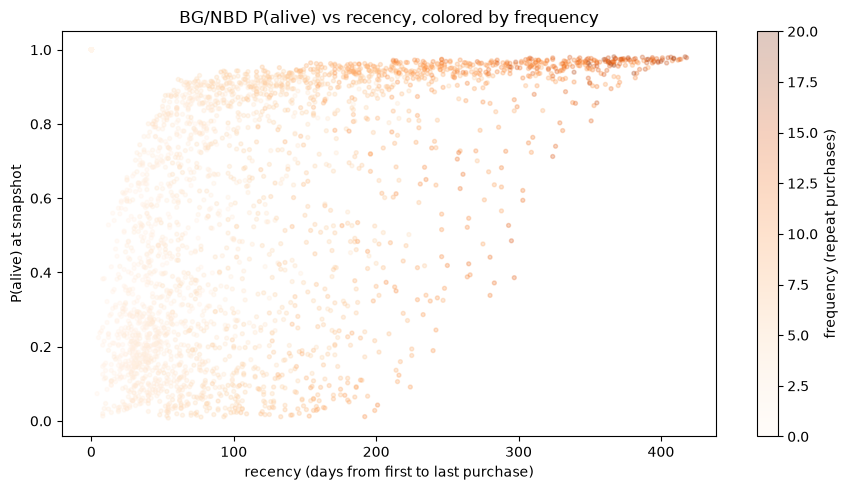

mean P(alive): 0.70
expected purchases in the next 90 days, total: 3,570


,frequency,recency,T,monetary_value,p_alive,expected_90d
customer_id,,,,,,
C02283,13.000,214.000,219.000,39.015,0.970,4.543
C01010,12.000,212.000,215.000,39.568,0.972,4.280
C00658,20.000,364.000,381.000,44.407,0.965,4.221
C03226,9.000,154.000,156.000,40.421,0.965,4.207
C01358,19.000,349.000,366.000,33.706,0.964,4.158


In [3]:
summary["p_alive"] = bgf.conditional_probability_alive(
    summary["frequency"], summary["recency"], summary["T"])
summary["expected_90d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90, summary["frequency"], summary["recency"], summary["T"])

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(summary["recency"], summary["p_alive"], s=8, alpha=0.25,
                c=summary["frequency"], cmap="Oranges")
plt.colorbar(sc, label="frequency (repeat purchases)")
ax.set_xlabel("recency (days from first to last purchase)")
ax.set_ylabel("P(alive) at snapshot")
ax.set_title("BG/NBD P(alive) vs recency, colored by frequency")
plt.tight_layout()
plt.show()
print(f"mean P(alive): {summary['p_alive'].mean():.2f}")
print(f"expected purchases in the next 90 days, total: {summary['expected_90d'].sum():,.0f}")
summary.sort_values("expected_90d", ascending=False).head()

## Gamma-Gamma and the independence assumption

Gamma-Gamma assumes spend per order is INDEPENDENT of purchase frequency. Check the correlation
first and say the number out loud - the assumption is often violated in real books. It also only
fits on returning customers (frequency > 0), because one-time buyers have no repeat spend to
model.

In [4]:
returning = summary[summary["frequency"] > 0].copy()
corr = returning[["frequency", "monetary_value"]].corr().iloc[0, 1]
print(f"corr(frequency, monetary_value) on returning customers = {corr:.3f}")
print("close to zero here, so the Gamma-Gamma independence assumption is defensible on this book")

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning["frequency"], returning["monetary_value"])
returning["clv_12m"] = ggf.customer_lifetime_value(
    bgf, returning["frequency"], returning["recency"], returning["T"],
    returning["monetary_value"], time=12, discount_rate=0.01, freq="D")
print(f"\nmodel CLV (12 months, 1% monthly discount): mean {returning['clv_12m'].mean():,.2f}, "
      f"median {returning['clv_12m'].median():,.2f}")
returning["clv_12m"].describe().round(2)

corr(frequency, monetary_value) on returning customers = -0.024
close to zero here, so the Gamma-Gamma independence assumption is defensible on this book

model CLV (12 months, 1% monthly discount): mean 174.96, median 116.16


count   2,642.000
mean      174.960
std       167.140
min         0.840
25%        23.340
50%       116.160
75%       303.660
max       827.000
Name: clv_12m, dtype: float64

## Honest LTV vs the napkin formula

Two ways to answer "what is a customer worth":

- **Honest ground truth**: take one mature cohort and accumulate its ACTUAL gross profit per
  original customer, month by month (revenue x 0.6 margin). No assumptions, just arithmetic on
  frozen history.
- **Napkin formula**: LTV = monthly ARPU x margin / monthly churn. It assumes churn is constant
  forever, but real churn falls with tenure (the loyal survive), so the geometric series and
  reality diverge. Plot both and see where the napkin lands.

cohort 2025-06: n=322, monthly ARPU=53.10, avg monthly churn=15.8%
napkin LTV = 53.10 x 0.6 / 0.158 = 201.17
honest cumulative gross profit per customer after 14 months = 120.73


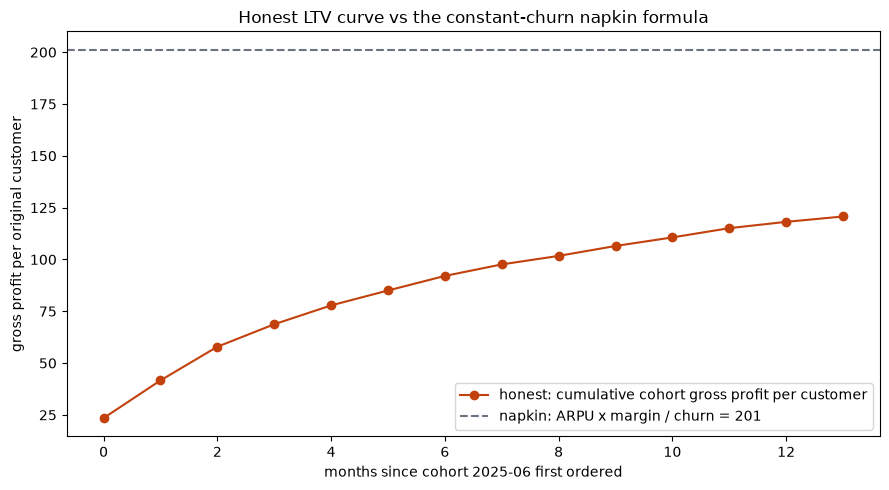

In [5]:
retail["order_month"] = retail["order_date"].dt.to_period("M")
retail["cohort"] = retail.groupby("customer_id")["order_date"].transform("min").dt.to_period("M")
first_cohort = retail["cohort"].min()
c0 = retail[retail["cohort"] == first_cohort]
n0 = c0["customer_id"].nunique()
monthly_rev = c0.groupby("order_month")["order_value"].sum().sort_index()
MARGIN = 0.6
honest = (monthly_rev.cumsum() * MARGIN / n0)

# napkin inputs measured on the same cohort
actives = c0.groupby("order_month")["customer_id"].nunique().sort_index()
arpu = (monthly_rev / actives).mean()                     # monthly revenue per active customer
surv = (actives.shift(-1) / actives).dropna()
churn = float(1 - surv.mean())                            # average month-over-month churn
napkin = arpu * MARGIN / churn
print(f"cohort {first_cohort}: n={n0:,}, monthly ARPU={arpu:,.2f}, avg monthly churn={churn:.1%}")
print(f"napkin LTV = {arpu:,.2f} x {MARGIN} / {churn:.3f} = {napkin:,.2f}")
print(f"honest cumulative gross profit per customer after {len(honest)} months = {honest.iloc[-1]:,.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(honest)), honest.values, marker="o", color="#C2410C",
        label="honest: cumulative cohort gross profit per customer")
ax.axhline(napkin, color="#6B7280", linestyle="--",
           label=f"napkin: ARPU x margin / churn = {napkin:,.0f}")
ax.set_xlabel(f"months since cohort {first_cohort} first ordered")
ax.set_ylabel("gross profit per original customer")
ax.set_title("Honest LTV curve vs the constant-churn napkin formula")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway**: the honest curve is still rising when the data ends while the napkin prints a
single flattering-or-not number from two averages. Use the napkin to sanity-check orders of
magnitude, use cumulative cohort gross profit (12-36 months) whenever real money decisions ride
on the answer, and remember the model CLV above inherits every BG/NBD assumption (irreversible
dropout, no seasonality, one-time buyers looking deceptively alive).